## 1. Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("spambase_csv.csv")
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
df.shape


(4601, 58)

In [ ]:
df.isnull().sum().sum()


np.int64(0)

## 2. Data Preprocessing

In [ ]:
X = df.drop(columns=['class'])
y = df['class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 3680
Test size: 921


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature scaling done")


Feature scaling done


## 3. Exploratory Data Analysis

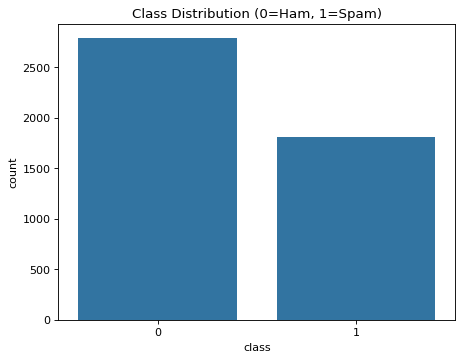

In [ ]:
sns.countplot(x='class', data=df)
plt.title("Class Distribution (0=Ham, 1=Spam)")
plt.show()


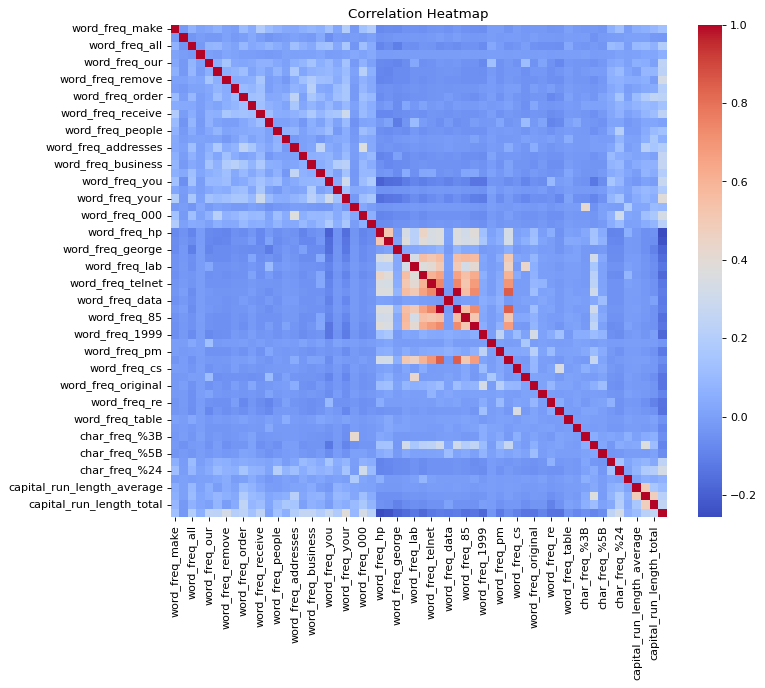

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## 4. Baseline Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, X_te, y_te, train_time):
    y_pred = model.predict(X_te)
    return {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1 Score': f1_score(y_te, y_pred),
        'Training Time (s)': train_time
    }

start = time.time()
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
lr_time = time.time() - start

lr_baseline_metrics = evaluate(log_reg, X_test, y_test, lr_time)
lr_baseline_metrics


{'Accuracy': 0.9294245385450597, 'Precision': 0.9209039548022598, 'Recall': 0.8980716253443526, 'F1 Score': 0.9093444909344491, 'Training Time (s)': 0.02936100959777832}

## 5. Logistic Regression Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='accuracy')
lr_grid.fit(X_train, y_train)

print("Best Params:", lr_grid.best_params_)
print("Best CV Accuracy:", round(lr_grid.best_score_, 3))


Best Params: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Best CV Accuracy: 0.924


In [ ]:
start = time.time()
best_lr = LogisticRegression(max_iter=1000, **lr_grid.best_params_)
best_lr.fit(X_train, y_train)
best_lr_time = time.time() - start

lr_final_metrics = evaluate(best_lr, X_test, y_test, best_lr_time)
lr_final_metrics


{'Accuracy': 0.9305103148751357, 'Precision': 0.9211267605633803, 'Recall': 0.9008264462809917, 'F1 Score': 0.9108635097493036, 'Training Time (s)': 2.3182010650634766}

## 6. SVM with Different Kernels

In [ ]:
from sklearn.svm import SVC

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []

for k in kernels:
    start = time.time()
    svm = SVC(kernel=k)
    svm.fit(X_train, y_train)
    k_time = time.time() - start

    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kernel_results.append([k, acc, f1, k_time])

kernel_table = pd.DataFrame(kernel_results, columns=['Kernel', 'Accuracy', 'F1 Score', 'Training Time (s)']).round(3)
kernel_table


,Kernel,Accuracy,F1 Score,Training Time (s)
0,linear,0.929,0.909,0.489
1,poly,0.780,0.622,0.472
2,rbf,0.927,0.906,0.205
3,sigmoid,0.885,0.853,0.242


## 7. SVM Hyperparameter Tuning

In [ ]:
svm_param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3, 4]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}
]

svm_grid = GridSearchCV(SVC(), svm_param_grid, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)

print("Best Params:", svm_grid.best_params_)
print("Best CV Accuracy:", round(svm_grid.best_score_, 3))


Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.933


In [ ]:
start = time.time()
best_svm = SVC(**svm_grid.best_params_)
best_svm.fit(X_train, y_train)
best_svm_time = time.time() - start

svm_final_metrics = evaluate(best_svm, X_test, y_test, best_svm_time)
svm_final_metrics


{'Accuracy': 0.9207383279044516, 'Precision': 0.9142857142857143, 'Recall': 0.8815426997245179, 'F1 Score': 0.8976157082748948, 'Training Time (s)': 0.191741943359375}

## 8. Hyperparameter Tuning Summary

In [ ]:
tuning_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'Search Method': ['Grid Search', 'Grid Search'],
    'Best Parameters': [lr_grid.best_params_, svm_grid.best_params_],
    'Best CV Accuracy': [round(lr_grid.best_score_,3), round(svm_grid.best_score_,3)]
})

tuning_summary


,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 10, 'penalty': 'l1', 'solver': 'saga'}",0.924
1,SVM,Grid Search,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.933


## 9. Model Performance Tables

In [ ]:
lr_performance = pd.DataFrame(lr_final_metrics, index=['Value']).T.round(4)
lr_performance


,Value
Accuracy,0.9305
Precision,0.9211
Recall,0.9008
F1 Score,0.9109
Training Time (s),2.3182


In [ ]:
kernel_table


,Kernel,Accuracy,F1 Score,Training Time (s)
0,linear,0.929,0.909,0.489
1,poly,0.780,0.622,0.472
2,rbf,0.927,0.906,0.205
3,sigmoid,0.885,0.853,0.242


## 10. K-Fold Cross Validation (K=5)

In [ ]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(best_lr, X_train, y_train, cv=5)
print("Logistic Regression CV Scores:", np.round(lr_cv_scores, 3))


Logistic Regression CV Scores: [0.94  0.916 0.923 0.917 0.924]


In [ ]:
svm_cv_scores = cross_val_score(best_svm, X_train, y_train, cv=5)
print("SVM CV Scores:", np.round(svm_cv_scores, 3))


SVM CV Scores: [0.943 0.932 0.933 0.921 0.936]


In [ ]:
cv_table = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5, 'Average'],
    'Logistic Regression': list(np.round(lr_cv_scores, 3)) + [round(lr_cv_scores.mean(), 3)],
    'SVM': list(np.round(svm_cv_scores, 3)) + [round(svm_cv_scores.mean(), 3)]
})

cv_table


,Fold,Logistic Regression,SVM
0,1,0.940,0.943
1,2,0.916,0.932
2,3,0.923,0.933
3,4,0.917,0.921
4,5,0.924,0.936
5,Average,0.924,0.933


## 11. Comparative Analysis

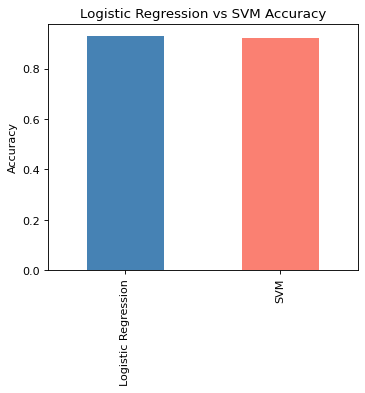

In [ ]:
comparison = pd.Series({
    'Logistic Regression': lr_final_metrics['Accuracy'],
    'SVM': svm_final_metrics['Accuracy']
})

comparison.plot(kind='bar', color=['steelblue', 'salmon'], figsize=(5,4))
plt.ylabel("Accuracy")
plt.title("Logistic Regression vs SVM Accuracy")
plt.show()


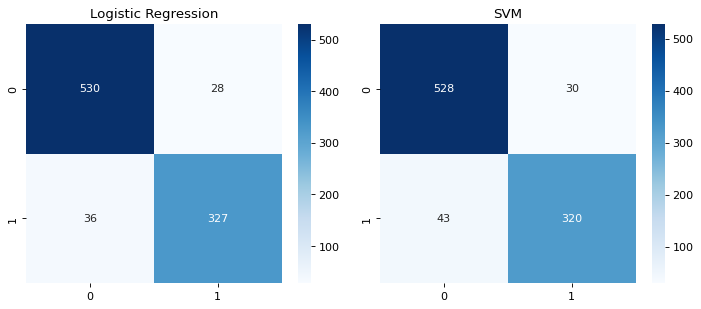

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(9,4))
sns.heatmap(confusion_matrix(y_test, best_lr.predict(X_test)), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")
sns.heatmap(confusion_matrix(y_test, best_svm.predict(X_test)), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("SVM")
plt.tight_layout()
plt.show()


In [ ]:
svm_train_time_label = 'High' if svm_final_metrics['Training Time (s)'] > lr_final_metrics['Training Time (s)'] else 'Low'
lr_train_time_label = 'Low' if svm_train_time_label == 'High' else 'High'

criterion_table = pd.DataFrame({
    'Logistic Regression': [round(lr_final_metrics['Accuracy'],3), 'Low', lr_train_time_label, 'High'],
    'SVM': [round(svm_final_metrics['Accuracy'],3), 'High', svm_train_time_label, 'Low']
}, index=['Accuracy', 'Model Complexity', 'Training Time', 'Interpretability'])

criterion_table


,Logistic Regression,SVM
Accuracy,0.931,0.921
Model Complexity,Low,High
Training Time,High,Low
Interpretability,High,Low


In [ ]:
if lr_final_metrics['Accuracy'] > svm_final_metrics['Accuracy']:
    print("Best performing classifier on test data: Logistic Regression")
else:
    print("Best performing classifier on test data: SVM")

print("Logistic Regression Accuracy:", round(lr_final_metrics['Accuracy'], 3))
print("SVM Accuracy:", round(svm_final_metrics['Accuracy'], 3))
0

Best performing classifier on test data: Logistic Regression
Logistic Regression Accuracy: 0.931
SVM Accuracy: 0.921
